## Feature engineering features and dealing with the problem as a regression problem

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smtsa
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HWES
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [109]:
#Reading the dataset of consumption, generation and pricing.
df1 = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/archive-3/energy_dataset.csv')

In [110]:
df1.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [111]:
df = df1[['time', 'total load actual']]

In [112]:
df.head()

,time,total load actual
0,2015-01-01 00:00:00+01:00,25385.0
1,2015-01-01 01:00:00+01:00,24382.0
2,2015-01-01 02:00:00+01:00,22734.0
3,2015-01-01 03:00:00+01:00,21286.0
4,2015-01-01 04:00:00+01:00,20264.0


In [113]:
#In each dataset 2 new variables will be created 'Time' and 'UTC Offset', to store the values of the timestamp
#and the UTC of each timezone.

df['Time'] = df1['time'].str.split('+', expand=True)[0]
df['UTC Offset'] = df1['time'].str.split('+', expand=True)[1]

In [114]:
#Converting the string of column 'Time' into a time serie

df['DateTime'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')

In [115]:
df['DateTime'].duplicated().sum()

np.int64(4)

In [116]:
df.drop_duplicates(subset = 'DateTime', inplace = True)

In [117]:
#Creating the datarange to assure the dataset contain all the points

start_date = df['DateTime'].min()
finish_date = df['DateTime'].max()
date_range = pd.date_range(start=start_date, end=finish_date, freq='1H')

In [118]:
#Setting the created DateRange to become the new index of the dataset|

df = df.set_index('DateTime').reindex(date_range).reset_index()

In [119]:
df.head()

,index,time,total load actual,Time,UTC Offset
0,2015-01-01 00:00:00,2015-01-01 00:00:00+01:00,25385.0,2015-01-01 00:00:00,01:00
1,2015-01-01 01:00:00,2015-01-01 01:00:00+01:00,24382.0,2015-01-01 01:00:00,01:00
2,2015-01-01 02:00:00,2015-01-01 02:00:00+01:00,22734.0,2015-01-01 02:00:00,01:00
3,2015-01-01 03:00:00,2015-01-01 03:00:00+01:00,21286.0,2015-01-01 03:00:00,01:00
4,2015-01-01 04:00:00,2015-01-01 04:00:00+01:00,20264.0,2015-01-01 04:00:00,01:00


In [120]:
df = df.interpolate(method='linear', limit_direction='both')  # Fill forward/backward

In [121]:
df.isnull().sum()

index                0
time                 4
total load actual    0
Time                 4
UTC Offset           4
dtype: int64

In [122]:
df.drop(columns = ['time', 'Time', 'UTC Offset'], inplace = True)

In [123]:
df.isnull().sum()

index                0
total load actual    0
dtype: int64

In [124]:
df.head()

,index,total load actual
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0
2,2015-01-01 02:00:00,22734.0
3,2015-01-01 03:00:00,21286.0
4,2015-01-01 04:00:00,20264.0


# Feature Engineering

In [125]:
df.rename(columns = {'index':'timestamp'}, inplace = True)

In [126]:
df.head()

,timestamp,total load actual
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0
2,2015-01-01 02:00:00,22734.0
3,2015-01-01 03:00:00,21286.0
4,2015-01-01 04:00:00,20264.0


In [127]:
#Converting DateTime in different columns.

weekdays = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3: 'Thursday', 4: 'Friday', 5:'Saturday', 6:'Sunday'}
months = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6: 'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'} 
df['year']=df['timestamp'].dt.year
df['month']=df['timestamp'].dt.month
df['day']=df['timestamp'].dt.day
df['hour']=df['timestamp'].dt.hour
df['weekday']=df['timestamp'].dt.weekday

In [128]:
df.head()

,timestamp,total load actual,year,month,day,hour,weekday
0,2015-01-01 00:00:00,25385.0,2015,1,1,0,3
1,2015-01-01 01:00:00,24382.0,2015,1,1,1,3
2,2015-01-01 02:00:00,22734.0,2015,1,1,2,3
3,2015-01-01 03:00:00,21286.0,2015,1,1,3,3
4,2015-01-01 04:00:00,20264.0,2015,1,1,4,3


In [129]:
df['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype=int32)

In [130]:
df['dayofyear'] = df['timestamp'].dt.dayofyear

In [131]:
df['weekofyear'] = df['timestamp'].dt.isocalendar()['week']

In [132]:
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['dow_sin'] = np.sin(2*np.pi*df['weekday']/7)
df['dow_cos'] = np.cos(2*np.pi*df['weekday']/7)
df['doy_sin'] = np.sin(2*np.pi*df['dayofyear']/366)
df['doy_cos'] = np.cos(2*np.pi*df['dayofyear']/366)

In [133]:
df['lag_1'] = df['total load actual'].shift(1)

In [134]:
df['lag_2'] = df['total load actual'].shift(2)

In [135]:
df['lag_3'] = df['total load actual'].shift(3)

In [136]:
df['lag_24'] = df['total load actual'].shift(24)

In [137]:
df['lag_168'] = df['total load actual'].shift(168)

In [138]:
df['load_rollmean_24'] = df['total load actual'].shift(1).rolling(24).mean()

In [139]:
df['load_rollmean_168'] = df['total load actual'].shift(1).rolling(168).mean()

In [140]:
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

In [141]:
df['woy_sin'] = np.sin(2*np.pi*df['weekofyear']/53)
df['woy_cos'] = np.cos(2*np.pi*df['weekofyear']/53)

In [142]:
df.head()

,timestamp,total load actual,year,month,day,hour,weekday,dayofyear,weekofyear,hour_sin,...,lag_2,lag_3,lag_24,lag_168,load_rollmean_24,load_rollmean_168,month_sin,month_cos,woy_sin,woy_cos
0,2015-01-01 00:00:00,25385.0,2015,1,1,0,3,1,1,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0.118273,0.992981
1,2015-01-01 01:00:00,24382.0,2015,1,1,1,3,1,1,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0.118273,0.992981
2,2015-01-01 02:00:00,22734.0,2015,1,1,2,3,1,1,0.500000,...,25385.0,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0.118273,0.992981
3,2015-01-01 03:00:00,21286.0,2015,1,1,3,3,1,1,0.707107,...,24382.0,25385.0,NaN,NaN,NaN,NaN,0.5,0.866025,0.118273,0.992981
4,2015-01-01 04:00:00,20264.0,2015,1,1,4,3,1,1,0.866025,...,22734.0,24382.0,NaN,NaN,NaN,NaN,0.5,0.866025,0.118273,0.992981


In [143]:
df.columns

Index(['timestamp', 'total load actual', 'year', 'month', 'day', 'hour',
       'weekday', 'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_168', 'load_rollmean_24', 'load_rollmean_168', 'month_sin',
       'month_cos', 'woy_sin', 'woy_cos'],
      dtype='object')

In [227]:
df_model2 = df.dropna().copy()

In [334]:
df_model = df.dropna().copy()

In [202]:
df_model2.columns

Index(['timestamp', 'total load actual', 'year', 'month', 'day', 'hour',
       'weekday', 'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_168', 'load_rollmean_24', 'load_rollmean_168', 'month_sin',
       'month_cos', 'woy_sin', 'woy_cos'],
      dtype='object')

In [145]:
df_model.columns

Index(['timestamp', 'total load actual', 'year', 'month', 'day', 'hour',
       'weekday', 'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_168', 'load_rollmean_24', 'load_rollmean_168', 'month_sin',
       'month_cos', 'woy_sin', 'woy_cos'],
      dtype='object')

In [228]:
df_model2.drop(columns = ['month', 'day', 'hour', 'weekday', 'dayofyear', 'weekofyear'], inplace = True)

In [147]:
df_model.head()

,timestamp,total load actual,year,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_24,lag_168,load_rollmean_24,load_rollmean_168,month_sin,month_cos,woy_sin,woy_cos
168,2015-01-08 00:00:00,26788.0,2015,0.000000,1.000000,0.433884,-0.900969,0.136906,0.990584,30477.0,32697.0,33716.0,30518.0,25385.0,32105.000000,26569.744048,0.5,0.866025,0.234886,0.972023
169,2015-01-08 01:00:00,25146.0,2015,0.258819,0.965926,0.433884,-0.900969,0.136906,0.990584,26788.0,30477.0,32697.0,28484.0,24382.0,31949.583333,26578.095238,0.5,0.866025,0.234886,0.972023
170,2015-01-08 02:00:00,23889.0,2015,0.500000,0.866025,0.433884,-0.900969,0.136906,0.990584,25146.0,26788.0,30477.0,27026.0,22734.0,31810.500000,26582.642857,0.5,0.866025,0.234886,0.972023
171,2015-01-08 03:00:00,23046.0,2015,0.707107,0.707107,0.433884,-0.900969,0.136906,0.990584,23889.0,25146.0,26788.0,26248.0,21286.0,31679.791667,26589.517857,0.5,0.866025,0.234886,0.972023
172,2015-01-08 04:00:00,22587.0,2015,0.866025,0.500000,0.433884,-0.900969,0.136906,0.990584,23046.0,23889.0,25146.0,25838.0,20264.0,31546.375000,26599.994048,0.5,0.866025,0.234886,0.972023


In [229]:
df_model2.drop(columns = ['timestamp'], inplace = True)

In [230]:
df_model2.columns

Index(['total load actual', 'year', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_168', 'load_rollmean_24', 'load_rollmean_168', 'month_sin',
       'month_cos', 'woy_sin', 'woy_cos'],
      dtype='object')

In [335]:
df_model.drop(columns = ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'load_rollmean_24', 'load_rollmean_168'], inplace = True)

In [339]:
df_model.drop(columns = ['timestamp'], inplace = True)

In [348]:
X = df_model.drop(columns = ['total load actual'])
y = df_model['total load actual']

In [349]:
df_model.shape

(34896, 18)

In [350]:
df_model.columns

Index(['total load actual', 'year', 'month', 'day', 'hour', 'weekday',
       'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'woy_sin', 'woy_cos'],
      dtype='object')

In [351]:
1485 / 34896

0.04255502063273728

In [352]:
X_train = X.iloc[:-5000]
X_val = X.iloc[-5000:-336]
X_test = X.iloc[-336:]
y_train = y.iloc[:-5000]
y_val = y.iloc[-5000:-336]
y_test = y.iloc[-336:]

In [353]:
X_train

,year,month,day,hour,weekday,dayofyear,weekofyear,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos,woy_sin,woy_cos
168,2015,1,8,0,3,8,2,0.000000e+00,1.000000,0.433884,-0.900969,0.136906,0.990584,5.000000e-01,0.866025,0.234886,0.972023
169,2015,1,8,1,3,8,2,2.588190e-01,0.965926,0.433884,-0.900969,0.136906,0.990584,5.000000e-01,0.866025,0.234886,0.972023
170,2015,1,8,2,3,8,2,5.000000e-01,0.866025,0.433884,-0.900969,0.136906,0.990584,5.000000e-01,0.866025,0.234886,0.972023
171,2015,1,8,3,3,8,2,7.071068e-01,0.707107,0.433884,-0.900969,0.136906,0.990584,5.000000e-01,0.866025,0.234886,0.972023
172,2015,1,8,4,3,8,2,8.660254e-01,0.500000,0.433884,-0.900969,0.136906,0.990584,5.000000e-01,0.866025,0.234886,0.972023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30059,2018,6,6,11,2,157,23,2.588190e-01,-0.965926,0.974928,-0.222521,0.431673,-0.902030,1.224647e-16,-1.000000,0.403123,-0.915146
30060,2018,6,6,12,2,157,23,1.224647e-16,-1.000000,0.974928,-0.222521,0.431673,-0.902030,1.224647e-16,-1.000000,0.403123,-0.915146
30061,2018,6,6,13,2,157,23,-2.588190e-01,-0.965926,0.974928,-0.222521,0.431673,-0.902030,1.224647e-16,-1.000000,0.403123,-0.915146
30062,2018,6,6,14,2,157,23,-5.000000e-01,-0.866025,0.974928,-0.222521,0.431673,-0.902030,1.224647e-16,-1.000000,0.403123,-0.915146


In [354]:
import lightgbm as lgb

In [355]:
# Method to calculate the predicted percentage of the dataframe
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [356]:
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000945 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1047
[LightGBM] [Info] Number of data points in the train set: 29896, number of used features: 17
[LightGBM] [Info] Start training from score 28645.857473
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[154]	valid_0's l1: 1599.15	valid_0's l2: 4.82197e+06


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [359]:
preds = model.predict(X_test)

In [360]:
print("R2", r2_score(y_test, preds))

R2 0.8848213526515603


In [361]:
mape = mape(y_test, preds)
print(mape)

4.437742652774931


In [362]:
y_test.index

Index([34728, 34729, 34730, 34731, 34732, 34733, 34734, 34735, 34736, 34737,
       ...
       35054, 35055, 35056, 35057, 35058, 35059, 35060, 35061, 35062, 35063],
      dtype='int64', length=336)

In [363]:
type(y_test)

pandas.core.series.Series

In [365]:
preds_df = pd.Series(preds, index = y_test.index)

Text(0.5, 1.0, 'Test and Predicted Test using Unobserved Components method')

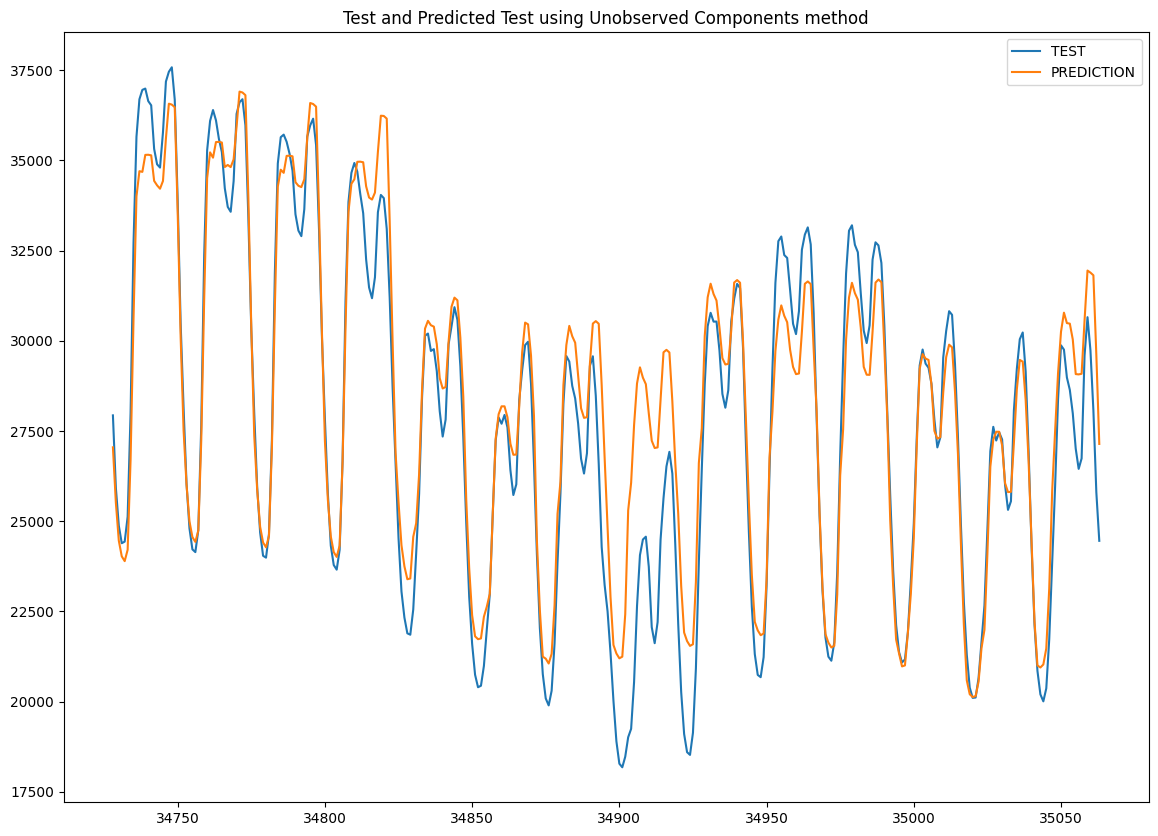

In [366]:
#Plotting predicted data against the original data.
y_test.plot(legend = True, label = 'TEST', figsize = (14, 10))
preds_df.plot(legend = True, label = 'PREDICTION')

# Display the title of the figure
plt.title('Test and Predicted Test using Unobserved Components method')

In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot


def plot_lgbm_diagnostics(y_true, y_pred, timestamps=None, lags=48, figsize=(12, 8)):
    residuals = pd.Series(np.asarray(y_true) - np.asarray(y_pred)).dropna()

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1) Standardized residuals over time
    std_resid = (residuals - residuals.mean()) / residuals.std(ddof=0)

    if timestamps is not None:
        axes[0, 0].plot(timestamps[:len(std_resid)], std_resid)
        axes[0, 0].set_xlabel("Time")
    else:
        axes[0, 0].plot(std_resid.values)

    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Standardized residuals")

    # 2) Histogram
    axes[0, 1].hist(std_resid, bins=30, density=True)
    axes[0, 1].set_title("Histogram of standardized residuals")

    # 3) Q-Q plot
    qqplot(std_resid, line="s", ax=axes[1, 0])
    axes[1, 0].set_title("Q-Q plot")

    # 4) ACF
    plot_acf(std_resid, lags=lags, ax=axes[1, 1])
    axes[1, 1].set_title("ACF of standardized residuals")

    plt.tight_layout()
    plt.show()

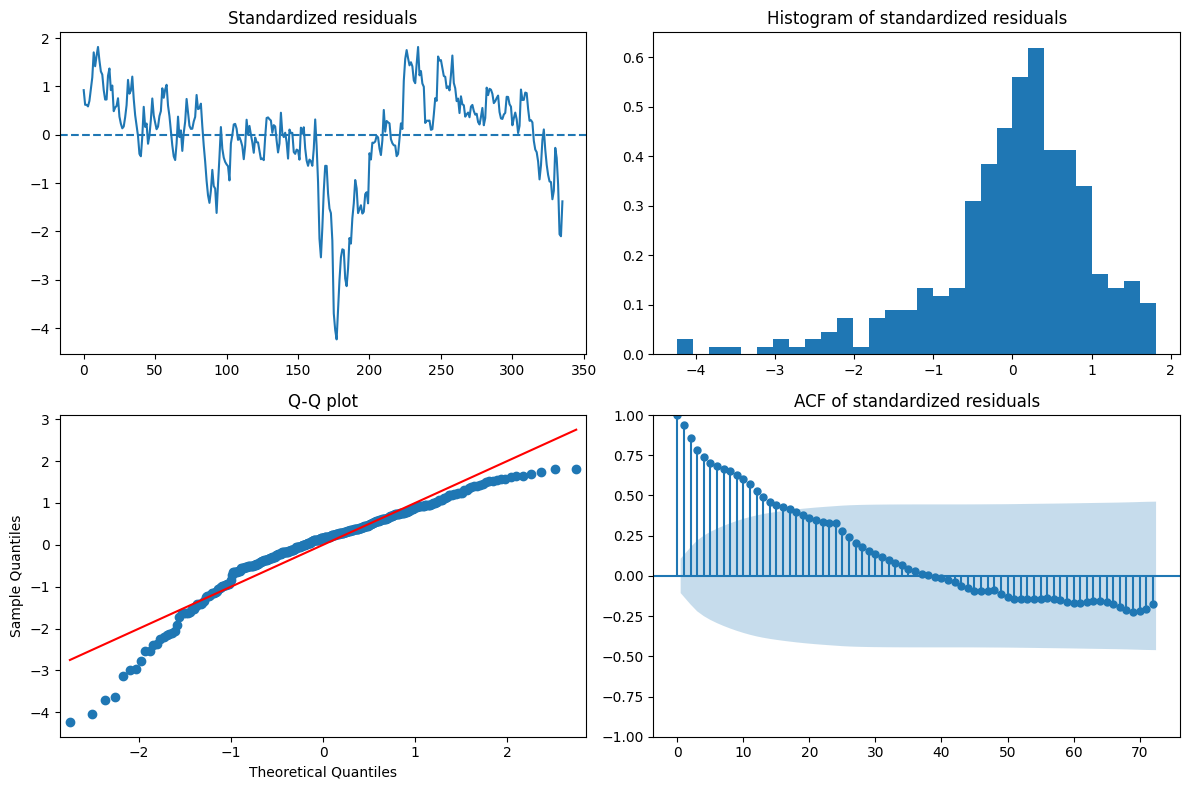

In [368]:
plot_lgbm_diagnostics(
    y_true=y_test,
    y_pred=preds,
    lags=72
)

In [ ]:
forecas

In [191]:
residuals = pd.Series(np.asarray(y_test) - preds)

In [192]:
residuals

0         19.157399
1         89.834534
2        689.697012
3       1332.815063
4       1958.081512
           ...     
1480    1426.300390
1481     490.291626
1482   -1173.708374
1483   -1995.001421
1484   -2314.713740
Length: 1485, dtype: float64

In [197]:
whole_predictions = model.predict(X)

In [198]:
residual = y - whole_predictions

In [199]:
residual

168       748.101096
169       546.815720
170       218.518802
171      -429.384389
172      -735.796261
            ...     
35059    1426.300390
35060     490.291626
35061   -1173.708374
35062   -1995.001421
35063   -2314.713740
Name: total load actual, Length: 34896, dtype: float64

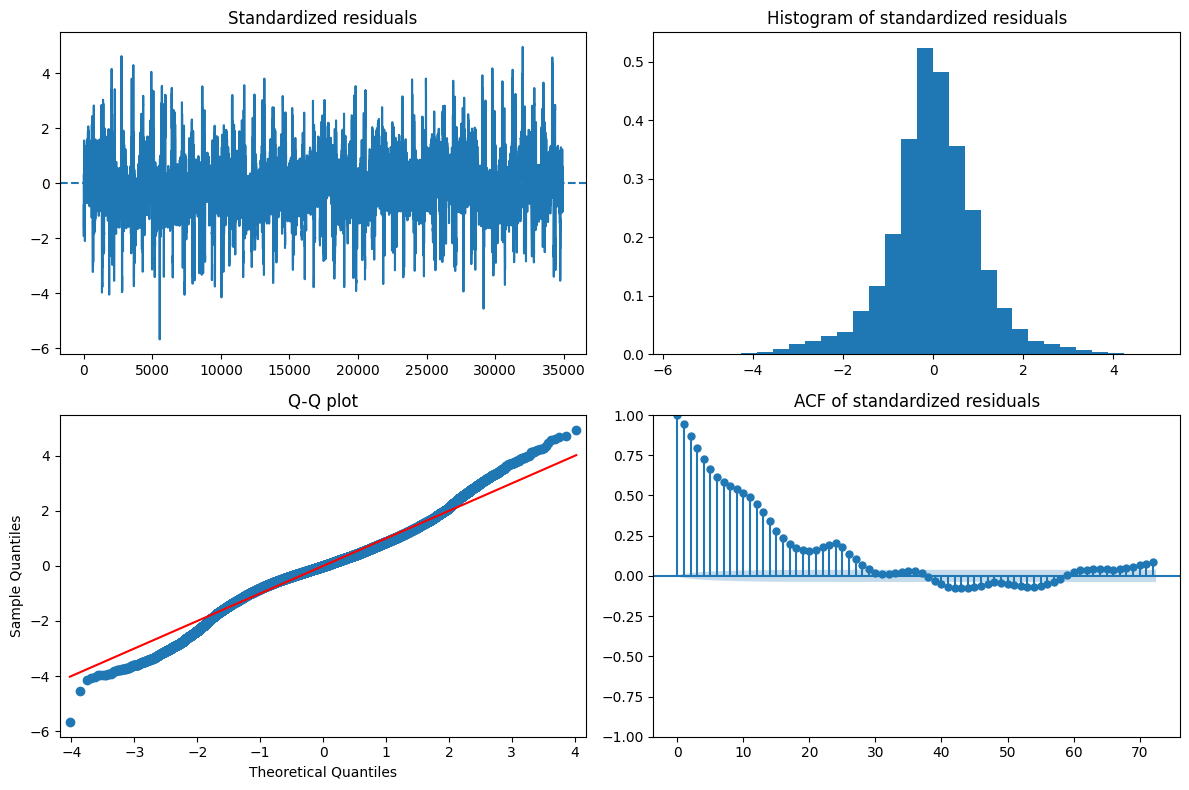

In [200]:
plot_lgbm_diagnostics(
    y_true=y,
    y_pred=whole_predictions,
    lags=72
)

In [213]:
df_model2

,year,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_24,lag_168,load_rollmean_24,load_rollmean_168,month_sin,month_cos,woy_sin,woy_cos
168,2015,0.000000,1.000000,0.433884,-0.900969,0.136906,0.990584,30477.0,32697.0,33716.0,30518.0,25385.0,32105.000000,26569.744048,5.000000e-01,0.866025,0.234886,0.972023
169,2015,0.258819,0.965926,0.433884,-0.900969,0.136906,0.990584,26788.0,30477.0,32697.0,28484.0,24382.0,31949.583333,26578.095238,5.000000e-01,0.866025,0.234886,0.972023
170,2015,0.500000,0.866025,0.433884,-0.900969,0.136906,0.990584,25146.0,26788.0,30477.0,27026.0,22734.0,31810.500000,26582.642857,5.000000e-01,0.866025,0.234886,0.972023
171,2015,0.707107,0.707107,0.433884,-0.900969,0.136906,0.990584,23889.0,25146.0,26788.0,26248.0,21286.0,31679.791667,26589.517857,5.000000e-01,0.866025,0.234886,0.972023
172,2015,0.866025,0.500000,0.433884,-0.900969,0.136906,0.990584,23046.0,23889.0,25146.0,25838.0,20264.0,31546.375000,26599.994048,5.000000e-01,0.866025,0.234886,0.972023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018,-0.965926,0.258819,0.000000,1.000000,-0.017166,0.999853,29592.0,26738.0,26449.0,29221.0,29570.0,26182.916667,26222.952381,-2.449294e-16,1.000000,0.118273,0.992981
35060,2018,-0.866025,0.500000,0.000000,1.000000,-0.017166,0.999853,30653.0,29592.0,26738.0,30042.0,28474.0,26242.583333,26229.398810,-2.449294e-16,1.000000,0.118273,0.992981
35061,2018,-0.707107,0.707107,0.000000,1.000000,-0.017166,0.999853,29735.0,30653.0,29592.0,30229.0,26583.0,26229.791667,26236.904762,-2.449294e-16,1.000000,0.118273,0.992981
35062,2018,-0.500000,0.866025,0.000000,1.000000,-0.017166,0.999853,28071.0,29735.0,30653.0,29145.0,24287.0,26139.875000,26245.761905,-2.449294e-16,1.000000,0.118273,0.992981


In [226]:
df_model2.head()

,year,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_24,lag_168,load_rollmean_24,load_rollmean_168,month_sin,month_cos,woy_sin,woy_cos
168,2015,0.000000,1.000000,0.433884,-0.900969,0.136906,0.990584,30477.0,32697.0,33716.0,30518.0,25385.0,32105.000000,26569.744048,0.5,0.866025,0.234886,0.972023
169,2015,0.258819,0.965926,0.433884,-0.900969,0.136906,0.990584,26788.0,30477.0,32697.0,28484.0,24382.0,31949.583333,26578.095238,0.5,0.866025,0.234886,0.972023
170,2015,0.500000,0.866025,0.433884,-0.900969,0.136906,0.990584,25146.0,26788.0,30477.0,27026.0,22734.0,31810.500000,26582.642857,0.5,0.866025,0.234886,0.972023
171,2015,0.707107,0.707107,0.433884,-0.900969,0.136906,0.990584,23889.0,25146.0,26788.0,26248.0,21286.0,31679.791667,26589.517857,0.5,0.866025,0.234886,0.972023
172,2015,0.866025,0.500000,0.433884,-0.900969,0.136906,0.990584,23046.0,23889.0,25146.0,25838.0,20264.0,31546.375000,26599.994048,0.5,0.866025,0.234886,0.972023


In [231]:
X = df_model2.drop(columns = ['total load actual'])
y = df_model2['total load actual']

In [319]:
X_train = X.iloc[:-3138]
y_train = y.iloc[:-3138]
X_val = X.iloc[-3138:-1653]
y_val = y.iloc[-3138:-1653]
X_pred = X.iloc[-1653:-1485]
y_pred = y.iloc[-1653:-1485]
y_test = y.iloc[-1485:]

In [234]:
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2447
[LightGBM] [Info] Number of data points in the train set: 31758, number of used features: 18
[LightGBM] [Info] Start training from score 28680.967866
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 292.907	valid_0's l2: 214289


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [320]:
X_pred.iloc[-1]

year                       2018.0
hour_sin                      0.5
hour_cos                 0.866025
dow_sin                  0.974928
dow_cos                 -0.222521
doy_sin                 -0.874481
doy_cos                   0.48506
lag_1                     24880.0
lag_2                     26566.0
lag_3                     28793.0
lag_24                    23648.0
lag_168                   22766.0
load_rollmean_24        30868.625
load_rollmean_168    27906.267857
month_sin               -0.866025
month_cos                     0.5
woy_sin                 -0.875735
woy_cos                  0.482792
Name: 33578, dtype: Float64

In [321]:
len(X_test)

1485

In [322]:
for n in range(len(X_test)):
    y_pred.loc[y_pred.index[-1]+1] = model.predict(X_pred.iloc[-1:])[0]
    X_pred_new = pd.DataFrame()
    X_pred_new = X_test.iloc[:n]
    X_pred_new['lag_1'] = y_pred.iloc[-2]
    X_pred_new['lag_2'] = y_pred.iloc[-3]
    X_pred_new['lag_3'] = y_pred.iloc[-4]
    X_pred_new['lag_24'] = y_pred.iloc[-25]
    X_pred_new['lag_168'] = y_pred.iloc[-169]
    X_pred_new['load_rollmean_24'] = y_pred.shift(1).rolling(24).mean().iloc[-1]
    X_pred_new['load_rollmean_168'] = y_pred.shift(1).rolling(168).mean().iloc[-1]
    X_pred = pd.concat([X_pred, X_pred_new])

In [326]:
y_test.tail()

35059    30653.0
35060    29735.0
35061    28071.0
35062    25801.0
35063    24455.0
Name: total load actual, dtype: float64

In [325]:
y_pred.tail()

35059    36769.149458
35060    38644.894949
35061    37565.448469
35062    38792.549596
35063    36920.652874
Name: total load actual, dtype: float64

In [331]:
y_prediction = y_pred.iloc[-1485:]

In [332]:
print("MAE:", mean_absolute_error(y_test, y_prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_prediction)))

MAE: 6005.929236980999
RMSE: 6975.280009670399


Text(0.5, 1.0, 'Test and Predicted Test using Unobserved Components method')

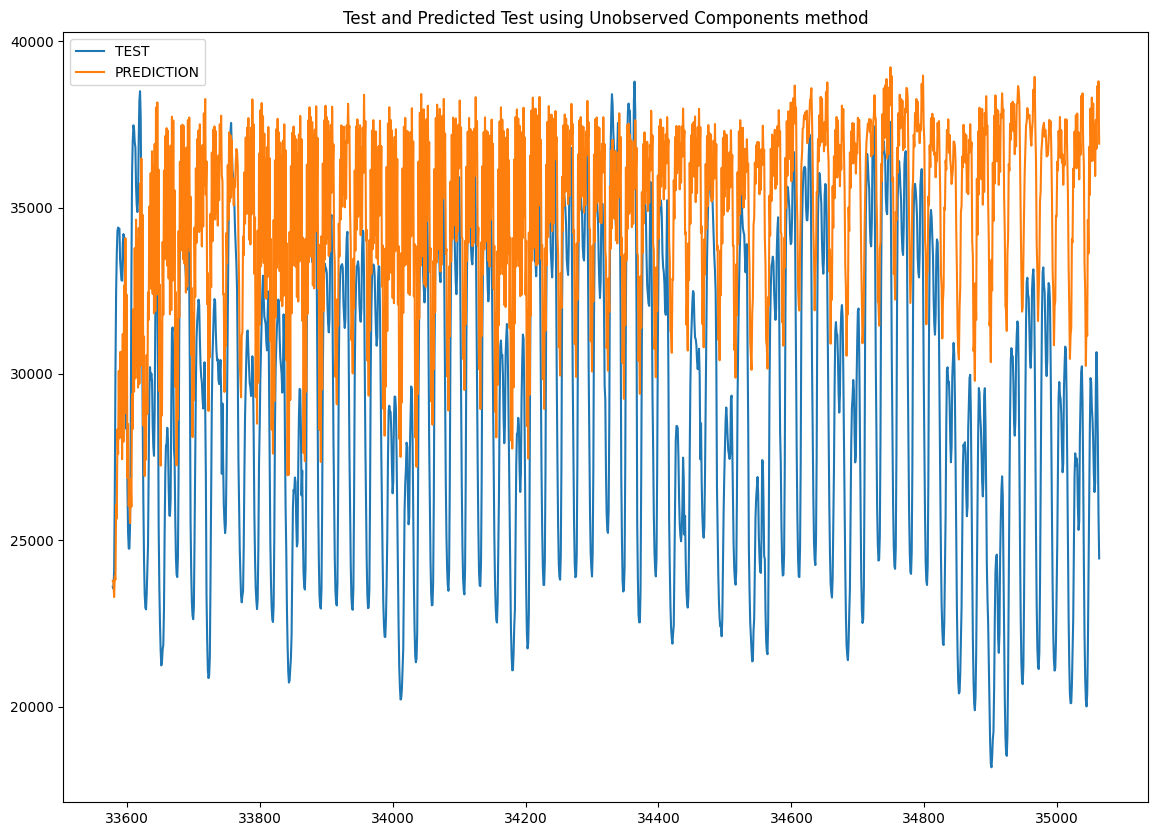

In [333]:
#Plotting predicted data against the original data.
y_test.plot(legend = True, label = 'TEST', figsize = (14, 10))
y_prediction.plot(legend = True, label = 'PREDICTION')

# Display the title of the figure
plt.title('Test and Predicted Test using Unobserved Components method')

In [369]:
import requests
import pandas as pd

cities = {
    "Madrid": (40.4168, -3.7038),
    "Barcelona": (41.3874, 2.1686),
    "Valencia": (39.4699, -0.3763),
    "Seville": (37.3891, -5.9845),
    "Bilbao": (43.2630, -2.9350),
}

all_dfs = []

for city, (lat, lon) in cities.items():
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2015-01-01",
        "end_date": "2018-12-31",
        "hourly": "temperature_2m",
        "timezone": "Europe/Madrid"
    }
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    df_city = pd.DataFrame({
        "timestamp": data["hourly"]["time"],
        "temperature_2m": data["hourly"]["temperature_2m"]
    })
    df_city["timestamp"] = pd.to_datetime(df_city["timestamp"])
    df_city["city"] = city
    all_dfs.append(df_city)

df_weather = pd.concat(all_dfs, ignore_index=True)
print(df_weather.head())

            timestamp  temperature_2m    city
0 2015-01-01 00:00:00            -2.2  Madrid
1 2015-01-01 01:00:00            -2.0  Madrid
2 2015-01-01 02:00:00            -2.0  Madrid
3 2015-01-01 03:00:00            -2.0  Madrid
4 2015-01-01 04:00:00            -1.7  Madrid


In [370]:
df_weather

,timestamp,temperature_2m,city
0,2015-01-01 00:00:00,-2.2,Madrid
1,2015-01-01 01:00:00,-2.0,Madrid
2,2015-01-01 02:00:00,-2.0,Madrid
3,2015-01-01 03:00:00,-2.0,Madrid
4,2015-01-01 04:00:00,-1.7,Madrid
...,...,...,...
175315,2018-12-31 19:00:00,6.8,Bilbao
175316,2018-12-31 20:00:00,6.1,Bilbao
175317,2018-12-31 21:00:00,5.4,Bilbao
175318,2018-12-31 22:00:00,4.7,Bilbao


In [373]:
df_weather_pivot = df_weather.pivot_table(values = 'temperature_2m', 
                                         index = 'timestamp',
                                         columns = 'city')

In [374]:
df_weather_pivot.head()

city,Barcelona,Bilbao,Madrid,Seville,Valencia
timestamp,,,,,
2015-01-01 00:00:00,5.7,5.8,-2.2,3.8,4.5
2015-01-01 01:00:00,4.5,4.3,-2.0,3.2,4.5
2015-01-01 02:00:00,4.7,3.5,-2.0,2.7,4.8
2015-01-01 03:00:00,5.3,2.9,-2.0,2.3,5.1
2015-01-01 04:00:00,5.4,2.5,-1.7,2.1,5.4
